# Variable-Width Quantile Bin Forecasting

This notebook keeps the two-day forecast horizon at 288 steps, but replaces equal-width bins with variable-width bins. Most scalar features use quantile bins, while the angular features keep equal-width bins. `Patv` bins are decoded with history-window medians rather than simple midpoints.


In [2]:
%pip install -q google-genai matplotlib


Note: you may need to restart the kernel to use updated packages.


In [ ]:
from pathlib import Path

DATA_PATH = "Your Data Path here"
GEMINI_API_KEY = "Your API key here"
TURB_ID = 1
FORECAST_START_DAY = 20
FORECAST_START_TMSTAMP = "00:00"
HISTORY_STEPS = int(144 * 14)
FORECAST_STEPS = 288
CHUNK_STEPS = 288
API_CALL_DELAY_SECONDS = 0
#MODEL_NAME = "gemini-2.5-flash"
MODEL_NAME = "gemini-3-flash-preview"
BIN_COUNT = 30
BINNED_FEATURES = ("Wspd", "Wdir", "Etmp", "Ndir", "Pab1", "Pab2", "Pab3", "Patv")


In [4]:
import os
import time
import textwrap

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from google import genai
from IPython.display import display
from pydantic import BaseModel, Field, ValidationError, field_validator

FORECAST_STEPS = int(FORECAST_STEPS)
CHUNK_STEPS = int(CHUNK_STEPS)
HISTORY_STEPS = int(HISTORY_STEPS)
BIN_COUNT = int(BIN_COUNT)
API_CALL_DELAY_SECONDS = int(API_CALL_DELAY_SECONDS)

if FORECAST_STEPS <= 0:
    raise ValueError("FORECAST_STEPS must be a positive integer.")
if CHUNK_STEPS <= 0:
    raise ValueError("CHUNK_STEPS must be a positive integer.")
if HISTORY_STEPS <= 0:
    raise ValueError("HISTORY_STEPS must be a positive integer.")
if BIN_COUNT <= 1:
    raise ValueError("BIN_COUNT must be greater than 1.")
if API_CALL_DELAY_SECONDS < 0:
    raise ValueError("API_CALL_DELAY_SECONDS must be zero or greater.")
if FORECAST_STEPS % CHUNK_STEPS != 0:
    raise ValueError("FORECAST_STEPS must be divisible by CHUNK_STEPS.")

CHUNK_COUNT = FORECAST_STEPS // CHUNK_STEPS
PROMPT_INPUT_COLUMNS = list(BINNED_FEATURES)
FEATURE_PREFIXES = {
    "Wspd": "WSPD",
    "Wdir": "WDIR",
    "Etmp": "ETMP",
    "Ndir": "NDIR",
    "Pab1": "PAB1",
    "Pab2": "PAB2",
    "Pab3": "PAB3",
    "Patv": "PATV",
}
FEATURE_BINNING_STRATEGY = {
    "Wspd": "quantile",
    "Wdir": "equal_width",
    "Etmp": "quantile",
    "Ndir": "equal_width",
    "Pab1": "quantile",
    "Pab2": "quantile",
    "Pab3": "quantile",
    "Patv": "quantile",
}
VALID_PATV_TOKENS = tuple(f"PATV_BIN_{idx:02d}" for idx in range(BIN_COUNT))


class ForecastChunkResponse(BaseModel):
    forecast_patv_bins: list[str] = Field(
        ...,
        min_length=CHUNK_STEPS,
        max_length=CHUNK_STEPS,
        description="Exactly CHUNK_STEPS PATV_BIN_XX tokens in chronological order.",
    )

    @field_validator("forecast_patv_bins")
    @classmethod
    def validate_patv_bins(cls, value: list[str]) -> list[str]:
        invalid = sorted({token for token in value if token not in VALID_PATV_TOKENS})
        if invalid:
            raise ValueError(f"Invalid PATV bin tokens: {invalid}")
        return value


In [5]:
def _tmstamp_to_step(tmstamp_series: pd.Series) -> pd.Series:
    hours = pd.to_numeric(tmstamp_series.str.slice(0, 2), errors="raise")
    minutes = pd.to_numeric(tmstamp_series.str.slice(3, 5), errors="raise")
    return (hours * 6 + (minutes // 10)).astype(int)


def load_turbine_data(data_path: Path, turb_id: int) -> pd.DataFrame:
    if not data_path.exists():
        raise FileNotFoundError(f"Dataset not found: {data_path}")

    usecols = [
        "TurbID",
        "Day",
        "Tmstamp",
        "Wspd",
        "Wdir",
        "Etmp",
        "Ndir",
        "Pab1",
        "Pab2",
        "Pab3",
        "Patv",
    ]

    frames = []
    for chunk in pd.read_csv(data_path, usecols=usecols, chunksize=200_000):
        chunk["TurbID"] = pd.to_numeric(chunk["TurbID"], errors="coerce")
        filtered = chunk.loc[chunk["TurbID"] == turb_id].copy()
        if not filtered.empty:
            frames.append(filtered)

    if not frames:
        raise ValueError(f"TurbID {turb_id} was not found in {data_path.name}.")

    df = pd.concat(frames, ignore_index=True)
    df["TurbID"] = pd.to_numeric(df["TurbID"], errors="raise").astype(int)
    df["Day"] = pd.to_numeric(df["Day"], errors="raise").astype(int)
    df["Tmstamp"] = df["Tmstamp"].astype(str)
    df["step_in_day"] = _tmstamp_to_step(df["Tmstamp"])

    df = df.sort_values(["Day", "step_in_day"], kind="stable").reset_index(drop=True)
    absolute_steps = (df["Day"] - 1) * 144 + df["step_in_day"]
    df["synthetic_timestamp"] = pd.Timestamp("2024-01-01") + pd.to_timedelta(absolute_steps * 10, unit="m")

    for column in PROMPT_INPUT_COLUMNS:
        df[column] = pd.to_numeric(df[column], errors="coerce")
        df[f"{column}_input"] = df[column].interpolate(limit_direction="both")

    remaining_missing = df[[f"{column}_input" for column in PROMPT_INPUT_COLUMNS]].isna().sum().sum()
    if remaining_missing:
        raise ValueError("Input interpolation left missing values behind; the notebook cannot build a clean prompt.")

    return df


def prepare_forecast_window(
    turbine_df: pd.DataFrame,
    forecast_start_day: int,
    forecast_start_tmstamp: str,
    history_steps: int,
    forecast_steps: int,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    start_matches = turbine_df.index[
        (turbine_df["Day"] == forecast_start_day)
        & (turbine_df["Tmstamp"] == forecast_start_tmstamp)
    ]

    if len(start_matches) == 0:
        raise ValueError(
            f"No row found for TurbID={int(turbine_df['TurbID'].iat[0])}, Day={forecast_start_day}, Tmstamp={forecast_start_tmstamp}."
        )
    if len(start_matches) > 1:
        raise ValueError("The requested forecast start is ambiguous; expected exactly one matching row.")

    start_idx = int(start_matches[0])
    if start_idx < history_steps:
        raise ValueError(
            f"Not enough history before Day={forecast_start_day}, Tmstamp={forecast_start_tmstamp}. Need {history_steps} rows, only have {start_idx}."
        )
    if start_idx + forecast_steps > len(turbine_df):
        raise ValueError(
            f"Not enough future rows after Day={forecast_start_day}, Tmstamp={forecast_start_tmstamp} for a {forecast_steps}-step forecast."
        )

    history_df = turbine_df.iloc[start_idx - history_steps : start_idx].copy()
    future_df = turbine_df.iloc[start_idx : start_idx + forecast_steps].copy()
    future_df["Patv_was_imputed"] = future_df["Patv"].isna()
    future_df["Patv_eval"] = future_df["Patv"].fillna(future_df["Patv_input"])

    if future_df["Patv_eval"].isna().any():
        raise ValueError("The future evaluation window still contains missing Patv values after interpolation.")

    return history_df, future_df


def fit_equal_width_bins(series: pd.Series, bin_count: int) -> np.ndarray:
    values = pd.to_numeric(series, errors="coerce").dropna().to_numpy(dtype=float)
    if values.size == 0:
        raise ValueError("Cannot fit bins on an empty series.")

    min_val = float(values.min())
    max_val = float(values.max())
    if np.isclose(min_val, max_val):
        pad = 0.5 if np.isclose(min_val, 0.0) else max(0.5, abs(min_val) * 0.05)
        min_val -= pad
        max_val += pad

    edges = np.linspace(min_val, max_val, bin_count + 1, dtype=float)
    if not np.all(np.diff(edges) > 0):
        raise ValueError("Bin edges must be strictly increasing.")
    return edges


def fit_quantile_bins(series: pd.Series, bin_count: int) -> np.ndarray:
    values = pd.to_numeric(series, errors="coerce").dropna().to_numpy(dtype=float)
    if values.size == 0:
        raise ValueError("Cannot fit bins on an empty series.")

    min_val = float(values.min())
    max_val = float(values.max())
    if np.isclose(min_val, max_val):
        pad = 0.5 if np.isclose(min_val, 0.0) else max(0.5, abs(min_val) * 0.05)
        min_val -= pad
        max_val += pad
        values = np.array([min_val, max_val], dtype=float)

    quantile_points = np.linspace(0.0, 1.0, bin_count + 1, dtype=float)
    try:
        edges = np.quantile(values, quantile_points, method="linear")
    except TypeError:
        edges = np.quantile(values, quantile_points, interpolation="linear")

    edges = np.asarray(edges, dtype=float)
    span = max(max_val - min_val, 1.0)
    eps = span * 1e-6
    edges[0] = min_val
    edges[-1] = max(max_val, edges[-2] + eps)
    for idx in range(1, len(edges)):
        if edges[idx] <= edges[idx - 1]:
            edges[idx] = edges[idx - 1] + eps

    return edges


def fit_feature_bins(feature: str, series: pd.Series, bin_count: int) -> tuple[np.ndarray, str]:
    strategy = FEATURE_BINNING_STRATEGY.get(feature, "quantile")
    if strategy == "quantile":
        return fit_quantile_bins(series, bin_count), strategy
    if strategy == "equal_width":
        return fit_equal_width_bins(series, bin_count), strategy
    raise ValueError(f"Unsupported binning strategy for {feature}: {strategy}")


def encode_to_bin_tokens(
    series: pd.Series | np.ndarray,
    edges: np.ndarray,
    prefix: str,
) -> tuple[list[str], np.ndarray]:
    values = np.asarray(series, dtype=float)
    if np.isnan(values).any():
        raise ValueError(f"{prefix} series contains NaN values; cannot encode bins.")

    clipped_flags = (values < edges[0]) | (values > edges[-1])
    clipped_values = np.clip(values, edges[0], edges[-1])
    bin_idx = np.searchsorted(edges, clipped_values, side="right") - 1
    bin_idx = np.clip(bin_idx, 0, len(edges) - 2).astype(int)
    tokens = [f"{prefix}_BIN_{idx:02d}" for idx in bin_idx]
    return tokens, clipped_flags


def compute_bin_decode_values(series: pd.Series, edges: np.ndarray) -> np.ndarray:
    values = pd.to_numeric(series, errors="coerce").dropna().to_numpy(dtype=float)
    if values.size == 0:
        raise ValueError("Cannot compute decode values from an empty series.")

    clipped_values = np.clip(values, edges[0], edges[-1])
    bin_idx = np.searchsorted(edges, clipped_values, side="right") - 1
    bin_idx = np.clip(bin_idx, 0, len(edges) - 2).astype(int)

    decode_values = []
    for idx in range(len(edges) - 1):
        in_bin = values[bin_idx == idx]
        if in_bin.size:
            decode_values.append(float(np.median(in_bin)))
        else:
            decode_values.append(float((edges[idx] + edges[idx + 1]) / 2.0))
    return np.asarray(decode_values, dtype=float)


def build_bin_specs(
    history_df: pd.DataFrame,
    binned_features: tuple[str, ...],
    bin_count: int,
) -> dict[str, dict[str, object]]:
    bin_specs: dict[str, dict[str, object]] = {}
    for feature in binned_features:
        prefix = FEATURE_PREFIXES[feature]
        edges, strategy = fit_feature_bins(feature, history_df[f"{feature}_input"], bin_count)
        decode_values = compute_bin_decode_values(history_df[f"{feature}_input"], edges)
        bin_specs[feature] = {
            "prefix": prefix,
            "edges": edges,
            "strategy": strategy,
            "decode_values": decode_values,
            "csv_col": f"{feature}_bin",
        }
    return bin_specs


def format_bin_dictionary(bin_specs: dict[str, dict[str, object]]) -> str:
    sections = []
    for feature in BINNED_FEATURES:
        spec = bin_specs[feature]
        prefix = str(spec["prefix"])
        edges = np.asarray(spec["edges"], dtype=float)
        strategy = str(spec["strategy"])
        lines = [f"{feature} bins ({strategy}):"]
        for idx in range(len(edges) - 1):
            left = edges[idx]
            right = edges[idx + 1]
            right_bracket = "]" if idx == len(edges) - 2 else ")"
            lines.append(f"{prefix}_BIN_{idx:02d} = [{left:.3f}, {right:.3f}{right_bracket}")
        sections.append("\n".join(lines))
    return "\n\n".join(sections)


def build_history_token_table(
    history_df: pd.DataFrame,
    bin_specs: dict[str, dict[str, object]],
) -> pd.DataFrame:
    prompt_table = history_df[["Day", "Tmstamp"]].copy()
    for feature in BINNED_FEATURES:
        spec = bin_specs[feature]
        tokens, _ = encode_to_bin_tokens(
            history_df[f"{feature}_input"],
            np.asarray(spec["edges"], dtype=float),
            str(spec["prefix"]),
        )
        prompt_table[str(spec["csv_col"])] = tokens
    return prompt_table


def build_predicted_continuation_csv(predicted_tokens: list[str]) -> str:
    if not predicted_tokens:
        return "None"

    continuation_df = pd.DataFrame(
        {
            "relative_step": np.arange(1, len(predicted_tokens) + 1, dtype=int),
            "Patv_bin": predicted_tokens,
        }
    )
    return continuation_df.to_csv(index=False)


def build_chunk_prompt(
    history_token_table: pd.DataFrame,
    bin_specs: dict[str, dict[str, object]],
    turb_id: int,
    forecast_start_day: int,
    forecast_start_tmstamp: str,
    history_steps: int,
    total_forecast_steps: int,
    chunk_steps: int,
    chunk_index: int,
    total_chunks: int,
    predicted_tokens_so_far: list[str],
) -> str:
    history_csv = history_token_table.to_csv(index=False)
    bin_dictionary = format_bin_dictionary(bin_specs)
    continuation_csv = build_predicted_continuation_csv(predicted_tokens_so_far)
    chunk_start_step = len(predicted_tokens_so_far) + 1
    chunk_end_step = chunk_start_step + chunk_steps - 1

    background_knowledge = textwrap.dedent(
        """
        Background knowledge:
        Wind turbine active power is driven mainly by wind speed, but the relationship is nonlinear rather than linear.
        Wind direction, nacelle direction, blade pitch, temperature, and recent active power jointly affect the output state.
        The feature values below are discretized into variable-width bins fit on the history window.
        Most scalar features use quantile bins, while wind direction and nacelle direction keep equal-width bins because they are angular variables.
        Higher bin indices generally represent larger values for that feature within this window.
        Use the joint token patterns across all features to infer the next active power state, rather than relying on a single feature alone.
        The rows are ordered from oldest to newest and each row represents a 10-minute timestep.
        """
    ).strip()

    task_statement = textwrap.dedent(
        f"""
        Task:
        You are given {history_steps} tokenized historical rows for turbine {turb_id}.
        The full target horizon is {total_forecast_steps} future steps beginning at Day {forecast_start_day}, Tmstamp {forecast_start_tmstamp}.
        You are now forecasting chunk {chunk_index} of {total_chunks}, which corresponds to relative future steps {chunk_start_step} through {chunk_end_step}.
        The predicted continuation block contains only prior predicted `Patv` bins from earlier chunks.
        Predict exactly the next {chunk_steps} `Patv` bins.
        """
    ).strip()

    bin_dictionary_block = textwrap.dedent(
        f"""
        Bin dictionary:
        {bin_dictionary}
        """
    ).strip()

    historical_block = textwrap.dedent(
        f"""
        Historical tokenized CSV data:
        {history_csv}
        """
    ).strip()

    continuation_block = textwrap.dedent(
        f"""
        Prior predicted continuation CSV:
        {continuation_csv}
        """
    ).strip()

    output_instruction = textwrap.dedent(
        f"""
        Output instruction:
        Return JSON only.
        Do not include markdown, prose, comments, or extra keys.
        The JSON must match this exact shape:
        {{"forecast_patv_bins": ["PATV_BIN_00", "PATV_BIN_01", ..., "{VALID_PATV_TOKENS[-1]}"]}}
        Return exactly {chunk_steps} tokens in chronological order.
        The only valid token values are: {', '.join(VALID_PATV_TOKENS)}.
        """
    ).strip()

    return "\n\n".join(
        [
            background_knowledge,
            task_statement,
            bin_dictionary_block,
            historical_block,
            continuation_block,
            output_instruction,
        ]
    )


def call_gemini_chunk_forecast(
    prompt: str,
    model_name: str,
    chunk_index: int,
    total_chunks: int,
) -> tuple[ForecastChunkResponse, str]:
    api_key = GEMINI_API_KEY.strip() if GEMINI_API_KEY else os.getenv("GEMINI_API_KEY")
    if not api_key:
        raise EnvironmentError(
            "No Gemini API key found. Paste it into GEMINI_API_KEY in the config cell or set the GEMINI_API_KEY environment variable."
        )

    client = genai.Client(api_key=api_key)
    response = client.models.generate_content(
        model=model_name,
        contents=prompt,
        config={
            "temperature": 0.0,
            "response_mime_type": "application/json",
            "response_json_schema": ForecastChunkResponse.model_json_schema(),
        },
    )

    raw_text = (response.text or "").strip()
    chunk_label = f"Chunk {chunk_index}/{total_chunks}"
    print("=" * 100)
    print(f"{chunk_label} raw Gemini response:")
    print(raw_text if raw_text else "[EMPTY RESPONSE]")
    print()

    if not raw_text:
        raise ValueError(f"{chunk_label} returned an empty response.")

    try:
        forecast = ForecastChunkResponse.model_validate_json(raw_text)
    except ValidationError as exc:
        preview = raw_text[:800] + ("..." if len(raw_text) > 800 else "")
        raise ValueError(
            f"{chunk_label} returned JSON that does not match ForecastChunkResponse. Response preview:\n{preview}"
        ) from exc

    if len(forecast.forecast_patv_bins) != CHUNK_STEPS:
        raise ValueError(
            f"{chunk_label} returned {len(forecast.forecast_patv_bins)} Patv bins; expected {CHUNK_STEPS}."
        )

    print(f"{chunk_label} parsed Patv bins:")
    print(forecast.forecast_patv_bins)
    print()
    return forecast, raw_text


def run_chunked_forecast(
    history_token_table: pd.DataFrame,
    bin_specs: dict[str, dict[str, object]],
    model_name: str,
    turb_id: int,
    forecast_start_day: int,
    forecast_start_tmstamp: str,
    history_steps: int,
    total_forecast_steps: int,
    chunk_steps: int,
    api_call_delay_seconds: int,
) -> dict[str, object]:
    if total_forecast_steps % chunk_steps != 0:
        raise ValueError("total_forecast_steps must be divisible by chunk_steps.")

    total_chunks = total_forecast_steps // chunk_steps
    stitched_tokens: list[str] = []
    chunk_records: list[dict[str, object]] = []

    for chunk_index in range(1, total_chunks + 1):
        chunk_start_step = len(stitched_tokens) + 1
        chunk_end_step = chunk_start_step + chunk_steps - 1
        prompt = build_chunk_prompt(
            history_token_table=history_token_table,
            bin_specs=bin_specs,
            turb_id=turb_id,
            forecast_start_day=forecast_start_day,
            forecast_start_tmstamp=forecast_start_tmstamp,
            history_steps=history_steps,
            total_forecast_steps=total_forecast_steps,
            chunk_steps=chunk_steps,
            chunk_index=chunk_index,
            total_chunks=total_chunks,
            predicted_tokens_so_far=stitched_tokens,
        )
        forecast, raw_text = call_gemini_chunk_forecast(
            prompt=prompt,
            model_name=model_name,
            chunk_index=chunk_index,
            total_chunks=total_chunks,
        )
        stitched_tokens.extend(forecast.forecast_patv_bins)
        chunk_records.append(
            {
                "chunk_index": chunk_index,
                "forecast_step_start": chunk_start_step,
                "forecast_step_end": chunk_end_step,
                "predicted_patv_bins": list(forecast.forecast_patv_bins),
                "raw_response_text": raw_text,
            }
        )
        if chunk_index < total_chunks and api_call_delay_seconds > 0:
            print(f"Waiting {api_call_delay_seconds} seconds before the next API call...")
            print()
            time.sleep(api_call_delay_seconds)

    return {
        "stitched_tokens": stitched_tokens,
        "chunk_records": chunk_records,
    }


def decode_patv_bins_to_values(tokens: list[str], patv_decode_values: np.ndarray) -> list[float]:
    decoded = []
    for token in tokens:
        if token not in VALID_PATV_TOKENS:
            raise ValueError(f"Unexpected Patv token: {token}")
        idx = int(token.rsplit("_", 1)[-1])
        decoded.append(float(patv_decode_values[idx]))
    return decoded


def label_true_future_bins(future_df: pd.DataFrame, patv_edges: np.ndarray) -> tuple[list[str], np.ndarray]:
    return encode_to_bin_tokens(future_df["Patv_eval"], patv_edges, FEATURE_PREFIXES["Patv"])


def score_forecast(actual_patv: pd.Series | np.ndarray, predicted_patv: list[float] | np.ndarray) -> dict[str, float]:
    actual = np.asarray(actual_patv, dtype=float)
    predicted = np.asarray(predicted_patv, dtype=float)

    if actual.shape != predicted.shape:
        raise ValueError(f"Shape mismatch: actual {actual.shape} vs predicted {predicted.shape}.")

    error = predicted - actual
    return {
        "MAE": float(np.mean(np.abs(error))),
        "RMSE": float(np.sqrt(np.mean(error ** 2))),
    }


def score_chunked_forecast(
    actual_patv: pd.Series | np.ndarray,
    predicted_patv: list[float] | np.ndarray,
    chunk_steps: int,
) -> pd.DataFrame:
    actual = np.asarray(actual_patv, dtype=float)
    predicted = np.asarray(predicted_patv, dtype=float)

    if actual.shape != predicted.shape:
        raise ValueError(f"Shape mismatch: actual {actual.shape} vs predicted {predicted.shape}.")
    if actual.size % chunk_steps != 0:
        raise ValueError("The forecast horizon must be divisible by chunk_steps.")

    rows = []
    chunk_count = actual.size // chunk_steps
    for idx in range(chunk_count):
        start = idx * chunk_steps
        stop = start + chunk_steps
        metrics = score_forecast(actual[start:stop], predicted[start:stop])
        rows.append(
            {
                "chunk_index": idx + 1,
                "forecast_step_start": start + 1,
                "forecast_step_end": stop,
                "MAE": metrics["MAE"],
                "RMSE": metrics["RMSE"],
            }
        )
    return pd.DataFrame(rows)


def plot_forecast(
    history_df: pd.DataFrame,
    future_df: pd.DataFrame,
    decoded_predicted_patv: list[float],
    chunk_steps: int,
) -> None:
    history_tail = history_df.tail(FORECAST_STEPS).copy()
    base_title = f"Turbine {int(history_df['TurbID'].iat[0])} variable-width chunked forecast from Day {int(future_df['Day'].iat[0])} {future_df['Tmstamp'].iat[0]}"
    future_timestamps = future_df["synthetic_timestamp"]

    plt.figure(figsize=(14, 5))
    plt.plot(
        history_tail["synthetic_timestamp"],
        history_tail["Patv_input"],
        label="Historical Patv (last horizon, imputed for prompt)",
        linewidth=1.8,
    )
    plt.plot(
        future_timestamps,
        future_df["Patv_eval"],
        label="Future Patv target (interpolated if needed)",
        linewidth=2.0,
    )
    plt.plot(
        future_timestamps,
        decoded_predicted_patv,
        label="Decoded Gemini Patv forecast (variable-width bin medians)",
        linestyle="--",
        linewidth=2.0,
    )

    for boundary_idx in range(chunk_steps, len(future_df), chunk_steps):
        boundary_ts = future_timestamps.iloc[boundary_idx]
        plt.axvline(boundary_ts, color="gray", linestyle=":", linewidth=1.0, alpha=0.35)

    plt.title(base_title)
    plt.xlabel("Synthetic timestamp")
    plt.ylabel("Patv")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(14, 5))
    plt.plot(
        future_timestamps,
        future_df["Patv_eval"],
        label="Future Patv target (interpolated if needed)",
        linewidth=2.0,
    )
    plt.plot(
        future_timestamps,
        decoded_predicted_patv,
        label="Decoded Gemini Patv forecast (variable-width bin medians)",
        linestyle="--",
        linewidth=2.0,
    )

    for boundary_idx in range(chunk_steps, len(future_df), chunk_steps):
        boundary_ts = future_timestamps.iloc[boundary_idx]
        plt.axvline(boundary_ts, color="gray", linestyle=":", linewidth=1.0, alpha=0.35)

    plt.title(f"{base_title} (future only)")
    plt.xlabel("Synthetic timestamp")
    plt.ylabel("Patv")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


Prepared 2016 history rows and 288 future rows for TurbID=1.
Chunk size: 288 steps
Delay between API calls: 0 seconds
Chunk count: 1
Future Patv values filled by interpolation for evaluation: 1
Patv binning strategy: quantile
Patv bin edges: [-2.65, -0.3, -0.298, -0.297, -0.295, -0.294, 0.0, 0.002, 0.003, 0.005, 35.007, 69.61, 114.82, 158.49, 202.487, 255.78, 330.463, 438.433, 547.2, 672.543, 814.72, 980.35, 1126.663, 1292.84, 1434.82, 1518.968, 1543.32, 1549.13, 1549.45, 1549.688, 1550.34]
Patv decode values: [-0.38, -0.3, -0.298, -0.296, -0.295, -0.105, 0.0, 0.002, 0.004, 17.86, 55.36, 88.71, 135.805, 178.35, 224.03, 286.74, 389.33, 500.07, 603.67, 740.71, 894.92, 1047.76, 1212.52, 1362.2, 1476.845, 1532.32, 1548.365, 1549.3, 1549.58, 1549.77]

Chunk 1/1 raw Gemini response:
{"forecast_patv_bins": ["PATV_BIN_24", "PATV_BIN_24", "PATV_BIN_24", "PATV_BIN_23", "PATV_BIN_23", "PATV_BIN_23", "PATV_BIN_23", "PATV_BIN_23", "PATV_BIN_22", "PATV_BIN_22", "PATV_BIN_22", "PATV_BIN_22", "PATV_BI

,MAE,RMSE
0,656.841267,781.543449


,chunk_index,forecast_step_start,forecast_step_end,MAE,RMSE
0,1,1,288,656.841267,781.543449


,chunk_index,forecast_step_start,forecast_step_end,predicted_patv_bins
0,1,1,288,"[PATV_BIN_24, PATV_BIN_24, PATV_BIN_24, PATV_B..."


,synthetic_timestamp,chunk_index,step_in_chunk,raw_patv,target_patv,true_patv_bin,predicted_patv_bin,decoded_predicted_patv,was_imputed,target_bin_was_clipped
0,2024-01-20 00:00:00,1,1,1516.59,1516.59,PATV_BIN_24,PATV_BIN_24,1476.845,False,False
1,2024-01-20 00:10:00,1,2,1510.54,1510.54,PATV_BIN_24,PATV_BIN_24,1476.845,False,False
2,2024-01-20 00:20:00,1,3,1507.68,1507.68,PATV_BIN_24,PATV_BIN_24,1476.845,False,False
3,2024-01-20 00:30:00,1,4,1503.67,1503.67,PATV_BIN_24,PATV_BIN_23,1362.200,False,False
4,2024-01-20 00:40:00,1,5,1469.88,1469.88,PATV_BIN_24,PATV_BIN_23,1362.200,False,False
5,2024-01-20 00:50:00,1,6,1449.74,1449.74,PATV_BIN_24,PATV_BIN_23,1362.200,False,False
6,2024-01-20 01:00:00,1,7,1450.99,1450.99,PATV_BIN_24,PATV_BIN_23,1362.200,False,False
7,2024-01-20 01:10:00,1,8,1381.91,1381.91,PATV_BIN_23,PATV_BIN_23,1362.200,False,False
8,2024-01-20 01:20:00,1,9,1374.99,1374.99,PATV_BIN_23,PATV_BIN_22,1212.520,False,False
9,2024-01-20 01:30:00,1,10,1337.28,1337.28,PATV_BIN_23,PATV_BIN_22,1212.520,False,False


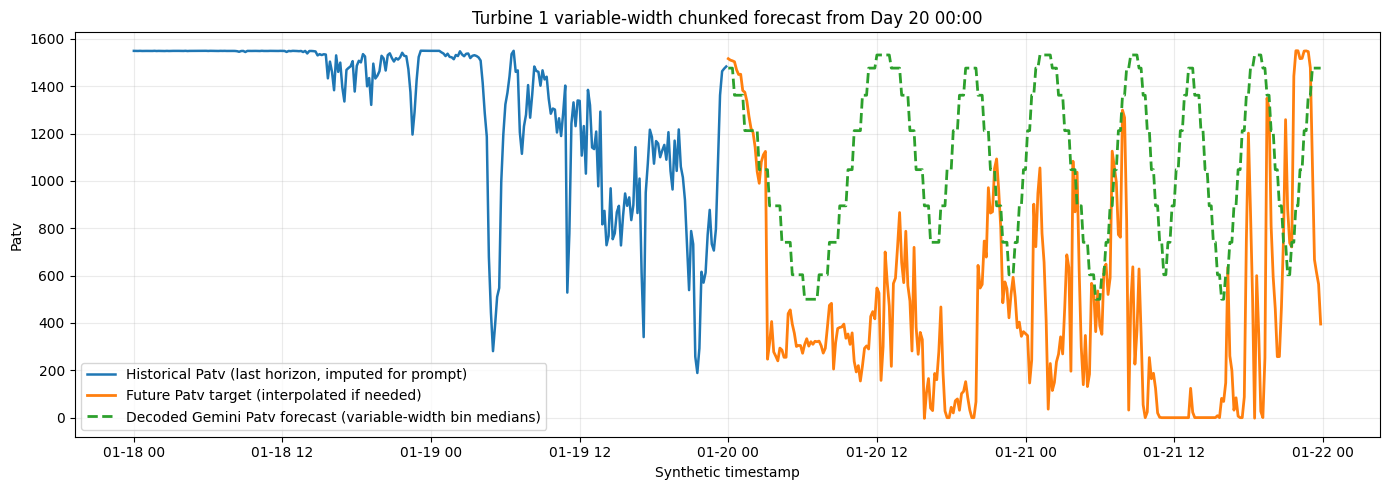

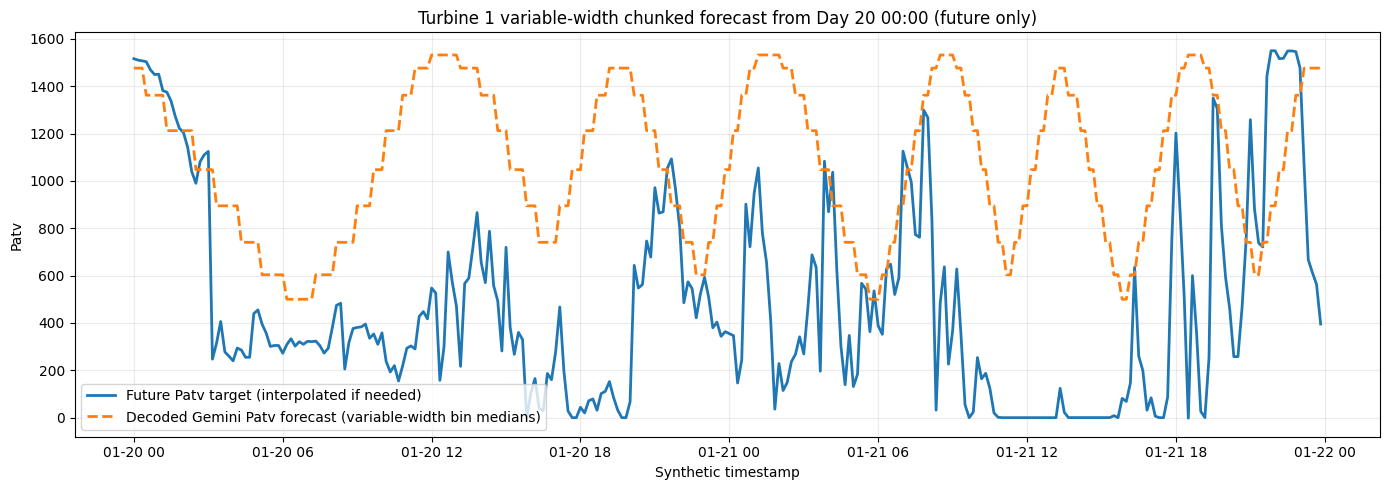

In [6]:
turbine_df = load_turbine_data(DATA_PATH, TURB_ID)
history_df, future_df = prepare_forecast_window(
    turbine_df=turbine_df,
    forecast_start_day=FORECAST_START_DAY,
    forecast_start_tmstamp=FORECAST_START_TMSTAMP,
    history_steps=HISTORY_STEPS,
    forecast_steps=FORECAST_STEPS,
)

bin_specs = build_bin_specs(history_df, BINNED_FEATURES, BIN_COUNT)
history_token_table = build_history_token_table(history_df, bin_specs)
future_imputed_count = int(future_df["Patv_was_imputed"].sum())

print(f"Prepared {len(history_df)} history rows and {len(future_df)} future rows for TurbID={TURB_ID}.")
print(f"Chunk size: {CHUNK_STEPS} steps")
print(f"Delay between API calls: {API_CALL_DELAY_SECONDS} seconds")
print(f"Chunk count: {CHUNK_COUNT}")
print(f"Future Patv values filled by interpolation for evaluation: {future_imputed_count}")
print(f"Patv binning strategy: {bin_specs['Patv']['strategy']}")
print(f"Patv bin edges: {np.round(bin_specs['Patv']['edges'], 3).tolist()}")
print(f"Patv decode values: {np.round(bin_specs['Patv']['decode_values'], 3).tolist()}")
print()

chunked_result = run_chunked_forecast(
    history_token_table=history_token_table,
    bin_specs=bin_specs,
    model_name=MODEL_NAME,
    turb_id=TURB_ID,
    forecast_start_day=FORECAST_START_DAY,
    forecast_start_tmstamp=FORECAST_START_TMSTAMP,
    history_steps=HISTORY_STEPS,
    total_forecast_steps=FORECAST_STEPS,
    chunk_steps=CHUNK_STEPS,
    api_call_delay_seconds=API_CALL_DELAY_SECONDS,
)
stitched_predicted_bins = chunked_result["stitched_tokens"]
decoded_predicted_patv = decode_patv_bins_to_values(
    stitched_predicted_bins,
    np.asarray(bin_specs["Patv"]["decode_values"], dtype=float),
)
true_patv_bins, target_bin_was_clipped = label_true_future_bins(
    future_df,
    np.asarray(bin_specs["Patv"]["edges"], dtype=float),
)
overall_metrics = score_forecast(future_df["Patv_eval"], decoded_predicted_patv)
chunk_metrics_df = score_chunked_forecast(future_df["Patv_eval"], decoded_predicted_patv, CHUNK_STEPS)

chunk_index = np.repeat(np.arange(1, CHUNK_COUNT + 1), CHUNK_STEPS)
step_in_chunk = np.tile(np.arange(1, CHUNK_STEPS + 1), CHUNK_COUNT)
comparison_df = pd.DataFrame(
    {
        "synthetic_timestamp": future_df["synthetic_timestamp"].to_numpy(),
        "chunk_index": chunk_index,
        "step_in_chunk": step_in_chunk,
        "raw_patv": future_df["Patv"].to_numpy(),
        "target_patv": future_df["Patv_eval"].to_numpy(),
        "true_patv_bin": true_patv_bins,
        "predicted_patv_bin": stitched_predicted_bins,
        "decoded_predicted_patv": decoded_predicted_patv,
        "was_imputed": future_df["Patv_was_imputed"].to_numpy(),
        "target_bin_was_clipped": target_bin_was_clipped,
    }
)
chunk_responses_df = pd.DataFrame(
    {
        "chunk_index": [record["chunk_index"] for record in chunked_result["chunk_records"]],
        "forecast_step_start": [record["forecast_step_start"] for record in chunked_result["chunk_records"]],
        "forecast_step_end": [record["forecast_step_end"] for record in chunked_result["chunk_records"]],
        "predicted_patv_bins": [record["predicted_patv_bins"] for record in chunked_result["chunk_records"]],
        "raw_response_text": [record["raw_response_text"] for record in chunked_result["chunk_records"]],
    }
)

print("All raw Gemini responses have been printed above and are also stored in chunk_responses_df['raw_response_text'].")
display(pd.DataFrame([overall_metrics]))
display(chunk_metrics_df)
display(chunk_responses_df[["chunk_index", "forecast_step_start", "forecast_step_end", "predicted_patv_bins"]])
display(comparison_df.head(30))
plot_forecast(history_df, future_df, decoded_predicted_patv, CHUNK_STEPS)


## 6 Hour Error

In [ ]:
# 6 hour error
if len(future_df) < 2:
    raise ValueError("Need at least two future rows to infer the forecast step size.")

step_minutes = int(
    (future_df["synthetic_timestamp"].iloc[1] - future_df["synthetic_timestamp"].iloc[0]).total_seconds() // 60
)
if step_minutes <= 0:
    raise ValueError(f"Invalid forecast step size: {step_minutes} minutes.")

first_six_hours_steps = int((6 * 60) // step_minutes)
if first_six_hours_steps <= 0:
    raise ValueError("The first-6-hours window must include at least one forecast step.")
if first_six_hours_steps > len(future_df):
    raise ValueError(
        f"The forecast only has {len(future_df)} steps, which is fewer than the first 6 hours ({first_six_hours_steps} steps)."
    )

first_six_hours_actual = future_df["Patv_eval"].iloc[:first_six_hours_steps]
first_six_hours_predicted = decoded_predicted_patv[:first_six_hours_steps]
first_six_hours_metrics = score_forecast(first_six_hours_actual, first_six_hours_predicted)
first_six_hours_chunk_metrics_df = score_chunked_forecast(
    first_six_hours_actual,
    first_six_hours_predicted,
    first_six_hours_steps,
)
first_six_hours_comparison_df = comparison_df.head(first_six_hours_steps).copy()

print(f"First 6 hours correspond to {first_six_hours_steps} forecast steps at {step_minutes} minutes per step.")
display(pd.DataFrame([first_six_hours_metrics]))
display(first_six_hours_chunk_metrics_df)
display(first_six_hours_comparison_df)




First 6 hours correspond to 36 forecast steps at 10 minutes per step.


,MAE,RMSE
0,253.836528,340.135087


,chunk_index,forecast_step_start,forecast_step_end,MAE,RMSE
0,1,1,36,253.836528,340.135087


,synthetic_timestamp,chunk_index,step_in_chunk,raw_patv,target_patv,true_patv_bin,predicted_patv_bin,decoded_predicted_patv,was_imputed,target_bin_was_clipped
0,2024-01-20 00:00:00,1,1,1516.59,1516.59,PATV_BIN_24,PATV_BIN_24,1476.845,False,False
1,2024-01-20 00:10:00,1,2,1510.54,1510.54,PATV_BIN_24,PATV_BIN_24,1476.845,False,False
2,2024-01-20 00:20:00,1,3,1507.68,1507.68,PATV_BIN_24,PATV_BIN_24,1476.845,False,False
3,2024-01-20 00:30:00,1,4,1503.67,1503.67,PATV_BIN_24,PATV_BIN_23,1362.200,False,False
4,2024-01-20 00:40:00,1,5,1469.88,1469.88,PATV_BIN_24,PATV_BIN_23,1362.200,False,False
5,2024-01-20 00:50:00,1,6,1449.74,1449.74,PATV_BIN_24,PATV_BIN_23,1362.200,False,False
6,2024-01-20 01:00:00,1,7,1450.99,1450.99,PATV_BIN_24,PATV_BIN_23,1362.200,False,False
7,2024-01-20 01:10:00,1,8,1381.91,1381.91,PATV_BIN_23,PATV_BIN_23,1362.200,False,False
8,2024-01-20 01:20:00,1,9,1374.99,1374.99,PATV_BIN_23,PATV_BIN_22,1212.520,False,False
9,2024-01-20 01:30:00,1,10,1337.28,1337.28,PATV_BIN_23,PATV_BIN_22,1212.520,False,False


## 3 Hour Error

In [10]:
# 3 hour error
if len(future_df) < 2:
    raise ValueError("Need at least two future rows to infer the forecast step size.")

step_minutes = int(
    (future_df["synthetic_timestamp"].iloc[1] - future_df["synthetic_timestamp"].iloc[0]).total_seconds() // 60
)
if step_minutes <= 0:
    raise ValueError(f"Invalid forecast step size: {step_minutes} minutes.")

first_three_hours_steps = int((3 * 60) // step_minutes)
if first_three_hours_steps <= 0:
    raise ValueError("The first-3-hours window must include at least one forecast step.")
if first_three_hours_steps > len(future_df):
    raise ValueError(
        f"The forecast only has {len(future_df)} steps, which is fewer than the first 3 hours ({first_three_hours_steps} steps)."
    )

first_three_hours_actual = future_df["Patv_eval"].iloc[:first_three_hours_steps]
first_three_hours_predicted = decoded_predicted_patv[:first_three_hours_steps]
first_three_hours_metrics = score_forecast(first_three_hours_actual, first_three_hours_predicted)
first_three_hours_chunk_metrics_df = score_chunked_forecast(
    first_three_hours_actual,
    first_three_hours_predicted,
    first_three_hours_steps,
)
first_three_hours_comparison_df = comparison_df.head(first_three_hours_steps).copy()

print(f"First 3 hours correspond to {first_three_hours_steps} forecast steps at {step_minutes} minutes per step.")
display(pd.DataFrame([first_three_hours_metrics]))
display(first_three_hours_chunk_metrics_df)
display(first_three_hours_comparison_df)

First 3 hours correspond to 18 forecast steps at 10 minutes per step.


,MAE,RMSE
0,72.904722,88.285296


,chunk_index,forecast_step_start,forecast_step_end,MAE,RMSE
0,1,1,18,72.904722,88.285296


,synthetic_timestamp,chunk_index,step_in_chunk,raw_patv,target_patv,true_patv_bin,predicted_patv_bin,decoded_predicted_patv,was_imputed,target_bin_was_clipped
0,2024-01-20 00:00:00,1,1,1516.59,1516.59,PATV_BIN_24,PATV_BIN_24,1476.845,False,False
1,2024-01-20 00:10:00,1,2,1510.54,1510.54,PATV_BIN_24,PATV_BIN_24,1476.845,False,False
2,2024-01-20 00:20:00,1,3,1507.68,1507.68,PATV_BIN_24,PATV_BIN_24,1476.845,False,False
3,2024-01-20 00:30:00,1,4,1503.67,1503.67,PATV_BIN_24,PATV_BIN_23,1362.200,False,False
4,2024-01-20 00:40:00,1,5,1469.88,1469.88,PATV_BIN_24,PATV_BIN_23,1362.200,False,False
5,2024-01-20 00:50:00,1,6,1449.74,1449.74,PATV_BIN_24,PATV_BIN_23,1362.200,False,False
6,2024-01-20 01:00:00,1,7,1450.99,1450.99,PATV_BIN_24,PATV_BIN_23,1362.200,False,False
7,2024-01-20 01:10:00,1,8,1381.91,1381.91,PATV_BIN_23,PATV_BIN_23,1362.200,False,False
8,2024-01-20 01:20:00,1,9,1374.99,1374.99,PATV_BIN_23,PATV_BIN_22,1212.520,False,False
9,2024-01-20 01:30:00,1,10,1337.28,1337.28,PATV_BIN_23,PATV_BIN_22,1212.520,False,False
